In [1]:
import pandas as pd

In [2]:
exercise = pd.read_csv('exercise.csv')
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [3]:
calories = pd.read_csv('calories.csv')
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [4]:
exercise.shape

(15000, 8)

In [5]:
calories.shape

(15000, 2)

In [6]:
df = pd.merge(exercise, calories, on ="User_ID", how = "inner")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
df.shape

(15000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [9]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [10]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


# Exploratory Data Analysis

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

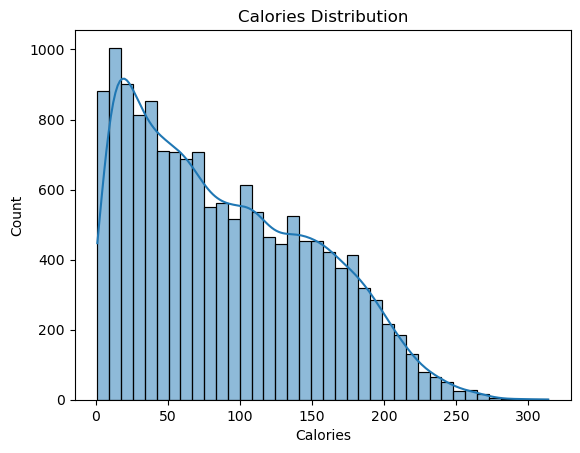

In [14]:
sns.histplot(df['Calories'], kde=True)
plt.title('Calories Distribution')
plt.show()

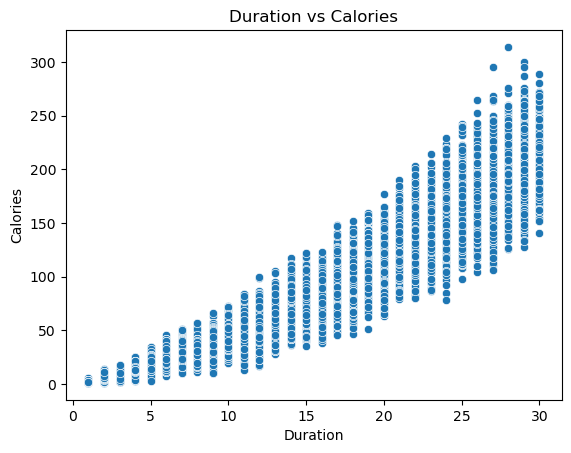

In [15]:
sns.scatterplot(x=df['Duration'], y=df['Calories'])
plt.title("Duration vs Calories")
plt.show()

In [16]:
df['Gender'] = df['Gender'].map({'male': 0, 'female': 1})

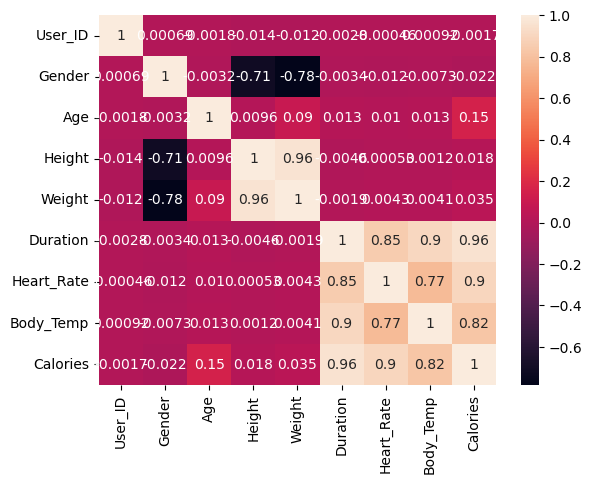

In [17]:
sns.heatmap(df.corr(), annot=True)
plt.show()

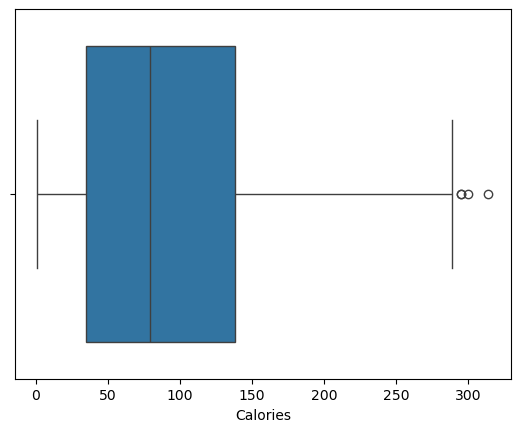

In [18]:
sns.boxplot(x=df['Calories'])
plt.show()

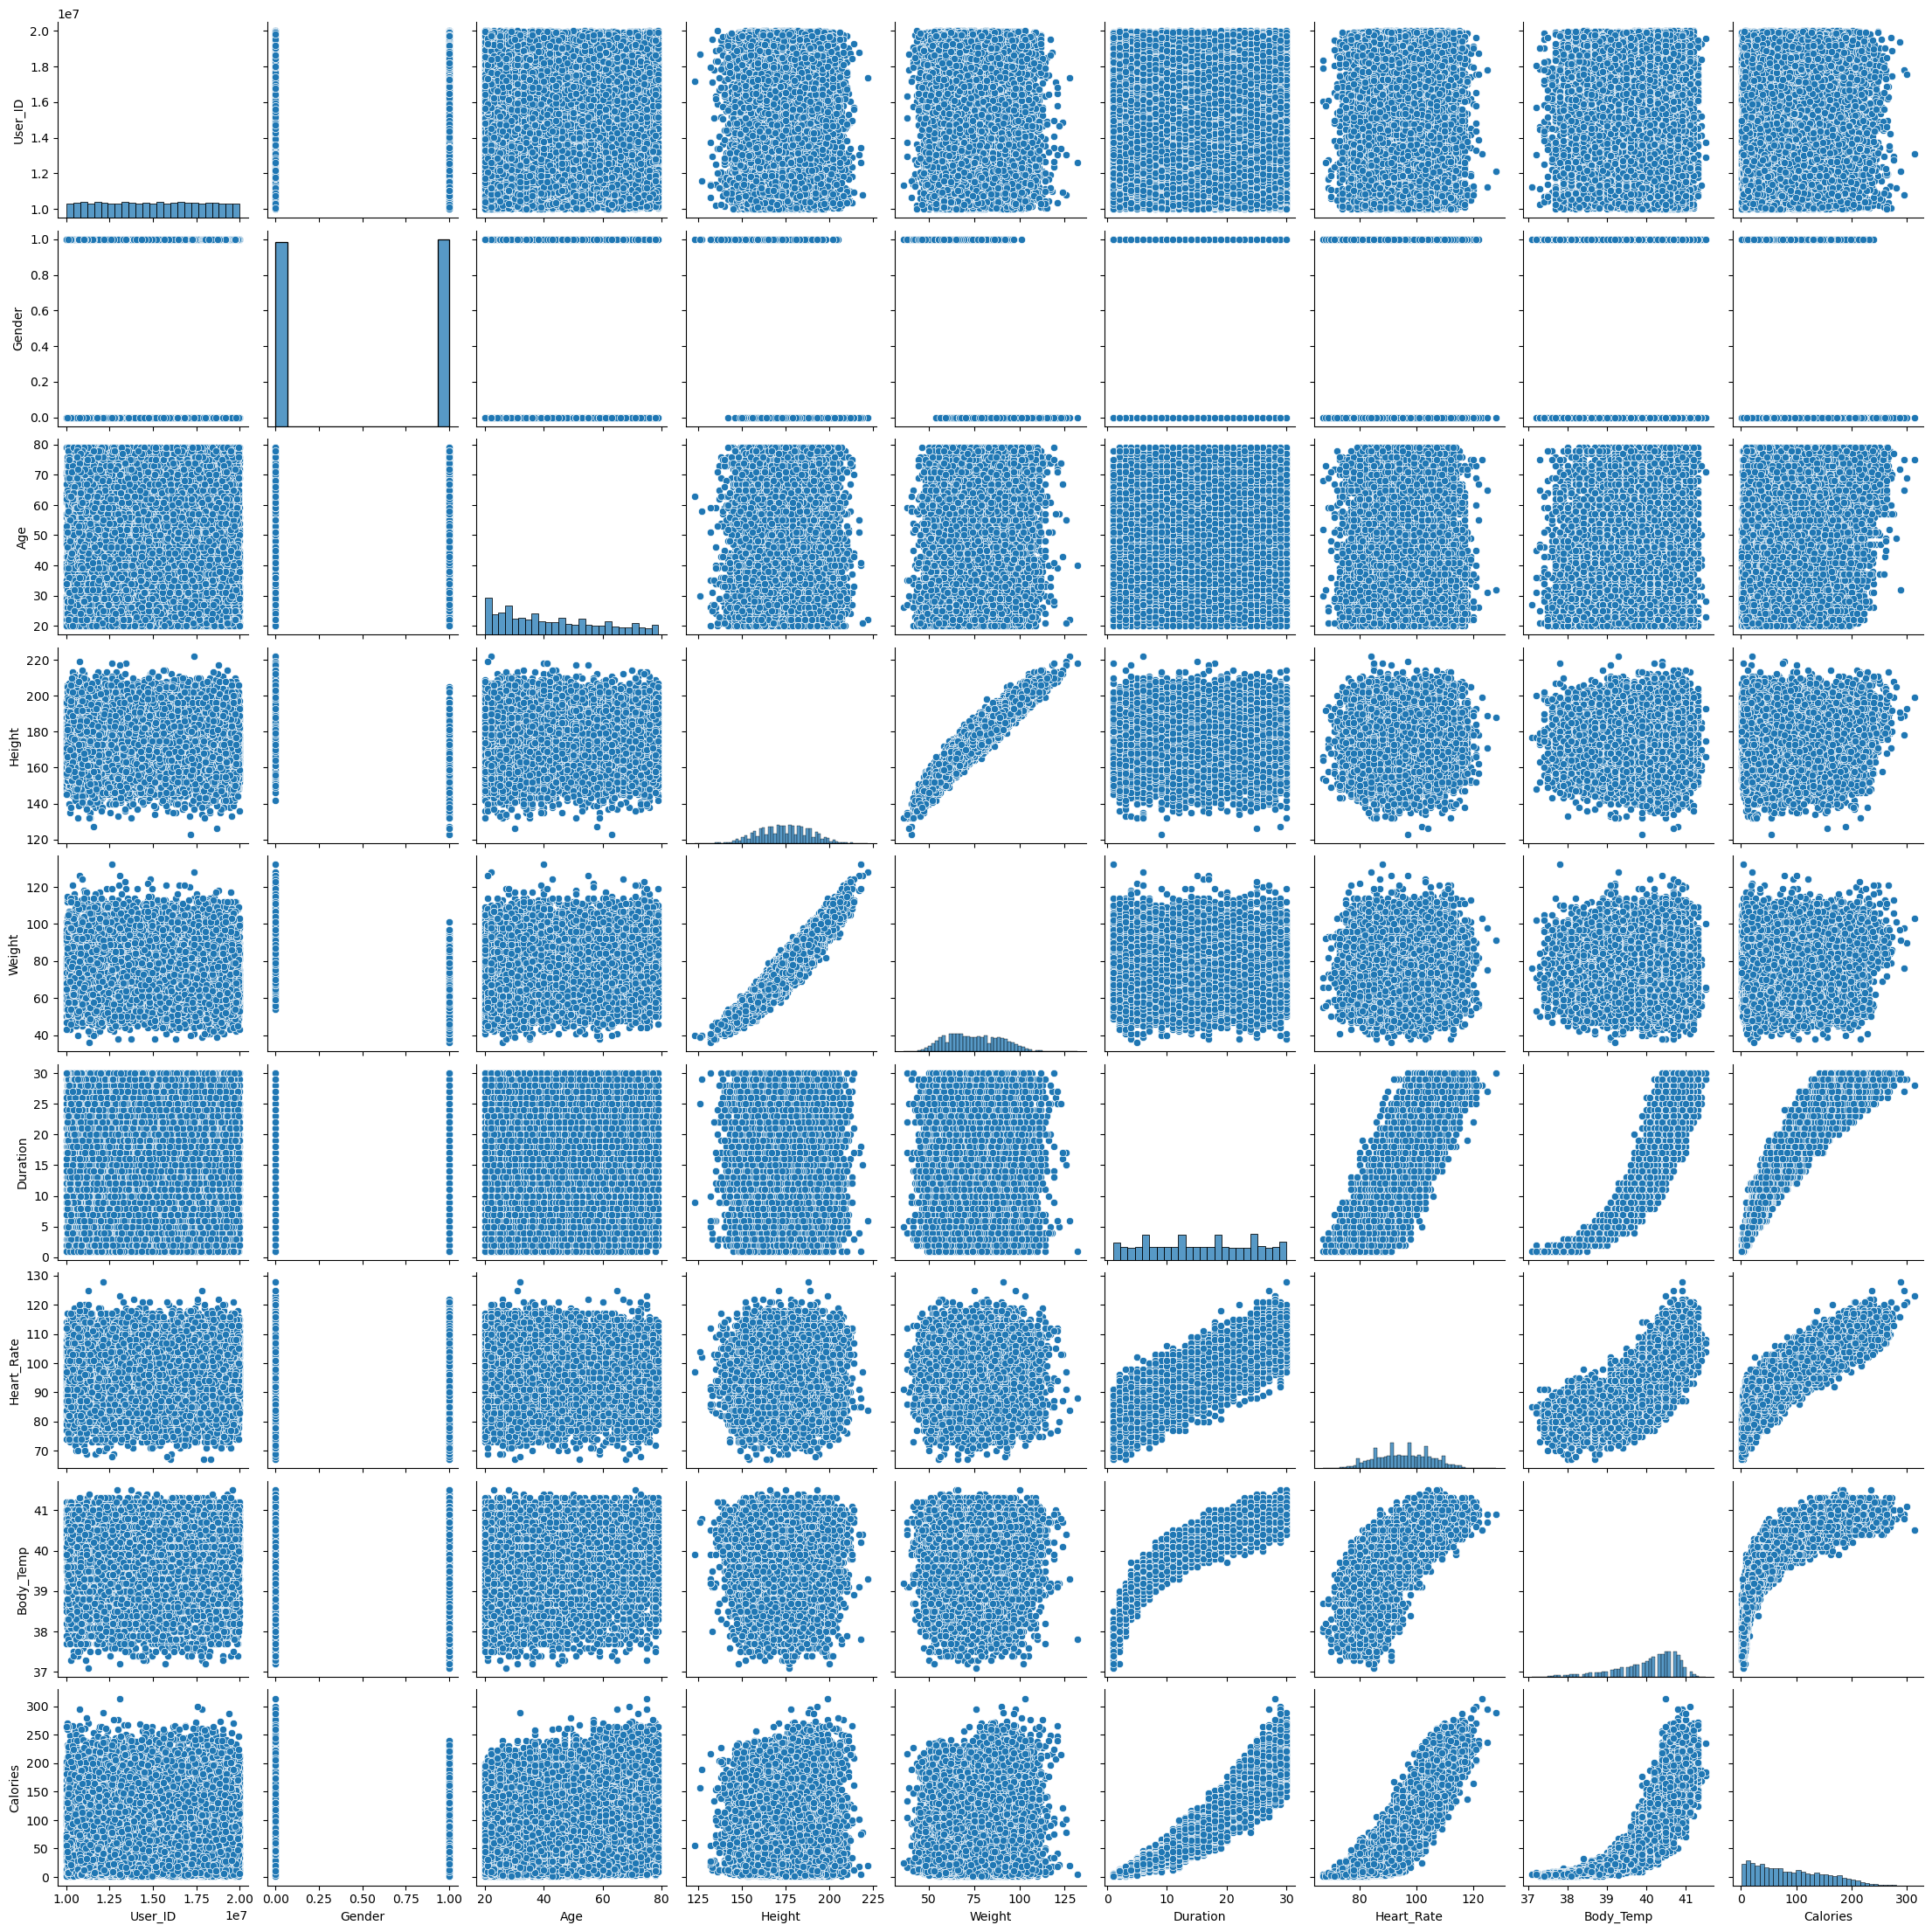

In [19]:
sns.pairplot(df)
plt.show()

# Feature Selection

In [20]:
X = df[['Age', 'Weight', 'Height', 'Duration', 'Heart_Rate', 'Body_Temp']]
y = df['Calories']

# Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12000, 6)
(3000, 6)


# Model 1

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

132.0268480349755


# Model 2

In [29]:
from sklearn.tree import DecisionTreeRegressor

In [30]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
y_pred_dt = dt_model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error

mse_dt = mean_squared_error(y_test, y_pred_dt)
print(mse_dt)

50.826


# Model 3

In [33]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred_rf = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import mean_squared_error

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(mse_rf)

18.642795433333333


# Model 4

In [37]:
from sklearn.neighbors import KNeighborsRegressor

In [38]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred_knn = knn_model.predict(X_test)

In [40]:
from sklearn.metrics import mean_squared_error

mse_knn = mean_squared_error(y_test, y_pred_knn)
print(mse_knn)

37.17198666666666


# Model 5

In [41]:
from sklearn.svm import SVR

In [42]:
svr_model = SVR()
svr_model.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [43]:
y_pred_svr = svr_model.predict(X_test)

In [44]:
from sklearn.metrics import mean_squared_error

mse_svr = mean_squared_error(y_test, y_pred_svr)
print(mse_svr)

45.01924708785099


In [45]:
df.to_csv("final_calories_data.csv", index=False)

In [46]:
import pickle

pickle.dump(rf_model, open("model.pkl", "wb"))

In [47]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, rf_pred)
r2   = r2_score(y_test, rf_pred)

print("Random Forest — Model Evaluation")
print(f"  MAE  : {mae:.2f}")
print(f"  MSE  : {mse:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}")

Random Forest — Model Evaluation
  MAE  : 2.53
  MSE  : 18.64
  RMSE : 4.32
  R²   : 0.9954


In [52]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='r2')

print("5-Fold Cross Validation Results")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i} R² : {score:.4f}")
print(f"  Mean R²  : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")


5-Fold Cross Validation Results
  Fold 1 R² : 0.9953
  Fold 2 R² : 0.9948
  Fold 3 R² : 0.9954
  Fold 4 R² : 0.9943
  Fold 5 R² : 0.9942
  Mean R²  : 0.9948
  Std Dev  : 0.0005


In [55]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("   Hyperparameter Tuning Results")
print(f"  Best Parameters : {grid_search.best_params_}")
print(f"  Best R² Score   : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
   Hyperparameter Tuning Results
  Best Parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Best R² Score   : 0.9942


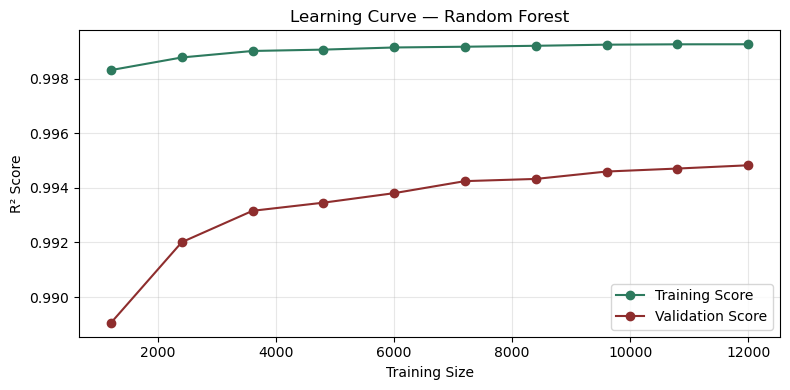

In [51]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_scaled, y,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, 'o-', color='#2d7a5e', label='Training Score')
plt.plot(train_sizes, val_mean,   'o-', color='#8e2d2d', label='Validation Score')
plt.title('Learning Curve — Random Forest')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()